# Code Snippets for plotting well logs in python

Remember you need to set up a conda or python environment for installing all the packages before loading and using them into these workflows

## Part II - Snippets for reading in and preparing data to plot and handle

In [ ]:
This assignment was completed by Jackson Smith, and shows various ways Python was used in Formation Evaluation Classwork to Analyze/Plott well logs.

In [19]:
# Importing packages
import os # to manage directories
import numpy as np # arrays
import pandas as pd # dataframes and data import
import matplotlib.pyplot as plt # to plot static 
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as patches


In [2]:
# Setting working directory to where you will have the data file stored
#os.chdir('/home/you/Spring_2025/Homework3/')


In [21]:
# Reading Excel with logs and header from current directory
df = pd.read_excel('HW2_data.xlsx',skiprows=37,header=None)
# New values for the first row to remove ~A (manually) character and change NPHI name
new_values='DEPTH        SP           RWA          RSFL         RILM         RILD         DT           GR           CALI         DPHI         NPHI_SS RHOB         '
# Change the contents of the first row
df.iloc[0] = new_values
#print(df.iloc[0])
#df.iloc[0]
df.columns 

Index([0], dtype='int64')

We currently only have one column with all logs within it as strings, so we need to separate them into columns based on the space characters presence and then convert them to numerical values

In [24]:
# Separating the one column into their corresponding
df2 = df[0].str.split(expand=True)

# Setting the first row as the header
df2.columns = df2.iloc[0]  # Set the first row as the header

# Removing the first row from the data and Reset the index
df2 = df2[1:].reset_index(drop=True) # reseting index for the data rows

# Now, we need to convert all values to numerical, as they are currently objects (Text/Strings)
df2 = df2.apply(pd.to_numeric, errors='coerce') #coerces the conversion of nonnumerical values to NaN
df2.head() # reading the first values of the dataframe to check

,DEPTH,SP,RWA,RSFL,RILM,RILD,DT,GR,CALI,DPHI,NPHI_SS,RHOB
0,5300.00,-0.251479,0.207594,0.944588,0.902729,0.902729,122.6844,84.419291,1.421834,30.295712,0.488664,2.150121
1,5300.25,-0.251479,0.213018,0.944588,0.910987,0.902729,122.6844,84.271654,1.421834,30.325283,0.490882,2.149633
2,5300.50,-0.251479,0.218442,0.944588,0.919246,0.902729,122.9794,84.124016,1.421834,30.354855,0.493100,2.149145
3,5300.75,-0.247546,0.221048,0.943543,0.918322,0.901765,123.4710,83.682239,1.420858,30.354855,0.492731,2.149145
4,5301.00,-0.243612,0.223654,0.942498,0.917398,0.900802,123.7752,83.240463,1.419882,30.354855,0.492363,2.149145


Then we check the data ranges with the describe function, finding values such as -999.25 which should be considered as NaN as well

In [27]:
# We need to convert the Caliper curve in feet to inches
df2['CALI_inches'] = df2['CALI'] * 12

In [29]:
df2.describe() # This gives descriptive statistics about each log

,DEPTH,SP,RWA,RSFL,RILM,RILD,DT,GR,CALI,DPHI,NPHI_SS,RHOB,CALI_inches
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,5550.000000,-37.672547,-19.643445,-13.612297,-16.930731,-16.380972,120.320567,61.436814,1.277422,32.444860,0.374356,2.114660,15.329059
std,144.445816,138.691963,139.943444,142.116191,140.468829,140.636946,13.097931,19.159930,0.119303,7.528386,0.115705,0.124218,1.431640
min,5300.000000,-999.250000,-999.250000,-999.250000,-999.250000,-999.250000,87.581100,25.388825,1.138569,20.744209,0.040956,1.716295,13.662829
25%,5425.000000,-34.491995,0.136943,0.890537,0.874538,0.862842,112.654900,42.013771,1.159367,27.957328,0.335190,2.087178,13.912402
50%,5550.000000,-13.084106,0.198032,0.957521,0.966240,0.957521,120.127800,64.622506,1.273293,30.975850,0.383767,2.138898,15.279519
75%,5675.000000,-0.695243,0.360915,1.956551,1.847553,1.908125,124.921500,79.145262,1.404587,34.110399,0.466190,2.188704,16.855045
max,5800.000000,3.047880,1.006410,191.570754,64.548813,58.232091,160.245800,94.064097,1.491612,56.588212,0.536865,2.307721,17.899346


Above, we can observe that the minimum values for many logs are -999.25, which is typically coded for not-logged in well logging companies. Thus, Data QC'ing further:

In [32]:
# We then replace them with NaN and check for the statistics again
df2.replace(-999.250000, np.nan, inplace=True) # Cleaning dataset by replacing -999.250000 with nan (not a number)
df2.describe() #check results with statistics

,DEPTH,SP,RWA,RSFL,RILM,RILD,DT,GR,CALI,DPHI,NPHI_SS,RHOB,CALI_inches
count,2001.000000,1961.000000,1961.000000,1961.000000,1961.000000,1961.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,5550.000000,-18.058525,0.338331,6.492501,3.106378,3.667351,120.320567,61.436814,1.277422,32.444860,0.374356,2.114660,15.329059
std,144.445816,19.315551,0.322297,19.458414,6.293189,8.082643,13.097931,19.159930,0.119303,7.528386,0.115705,0.124218,1.431640
min,5300.000000,-60.157748,0.040946,0.408385,0.374686,0.334551,87.581100,25.388825,1.138569,20.744209,0.040956,1.716295,13.662829
25%,5425.000000,-33.024167,0.141511,0.894549,0.878510,0.872559,112.654900,42.013771,1.159367,27.957328,0.335190,2.087178,13.912402
50%,5550.000000,-10.921774,0.199564,0.961824,0.970630,0.957566,120.127800,64.622506,1.273293,30.975850,0.383767,2.138898,15.279519
75%,5675.000000,-0.671788,0.383214,2.032065,1.950757,1.977465,124.921500,79.145262,1.404587,34.110399,0.466190,2.188704,16.855045
max,5800.000000,3.047880,1.006410,191.570754,64.548813,58.232091,160.245800,94.064097,1.491612,56.588212,0.536865,2.307721,17.899346


We can see that the statistics make sense in regards of values for each well log

## Tutorial for plotting

We encourage you to play with this code, and understand how to plot with this method, using subplots, and what each parameter does.

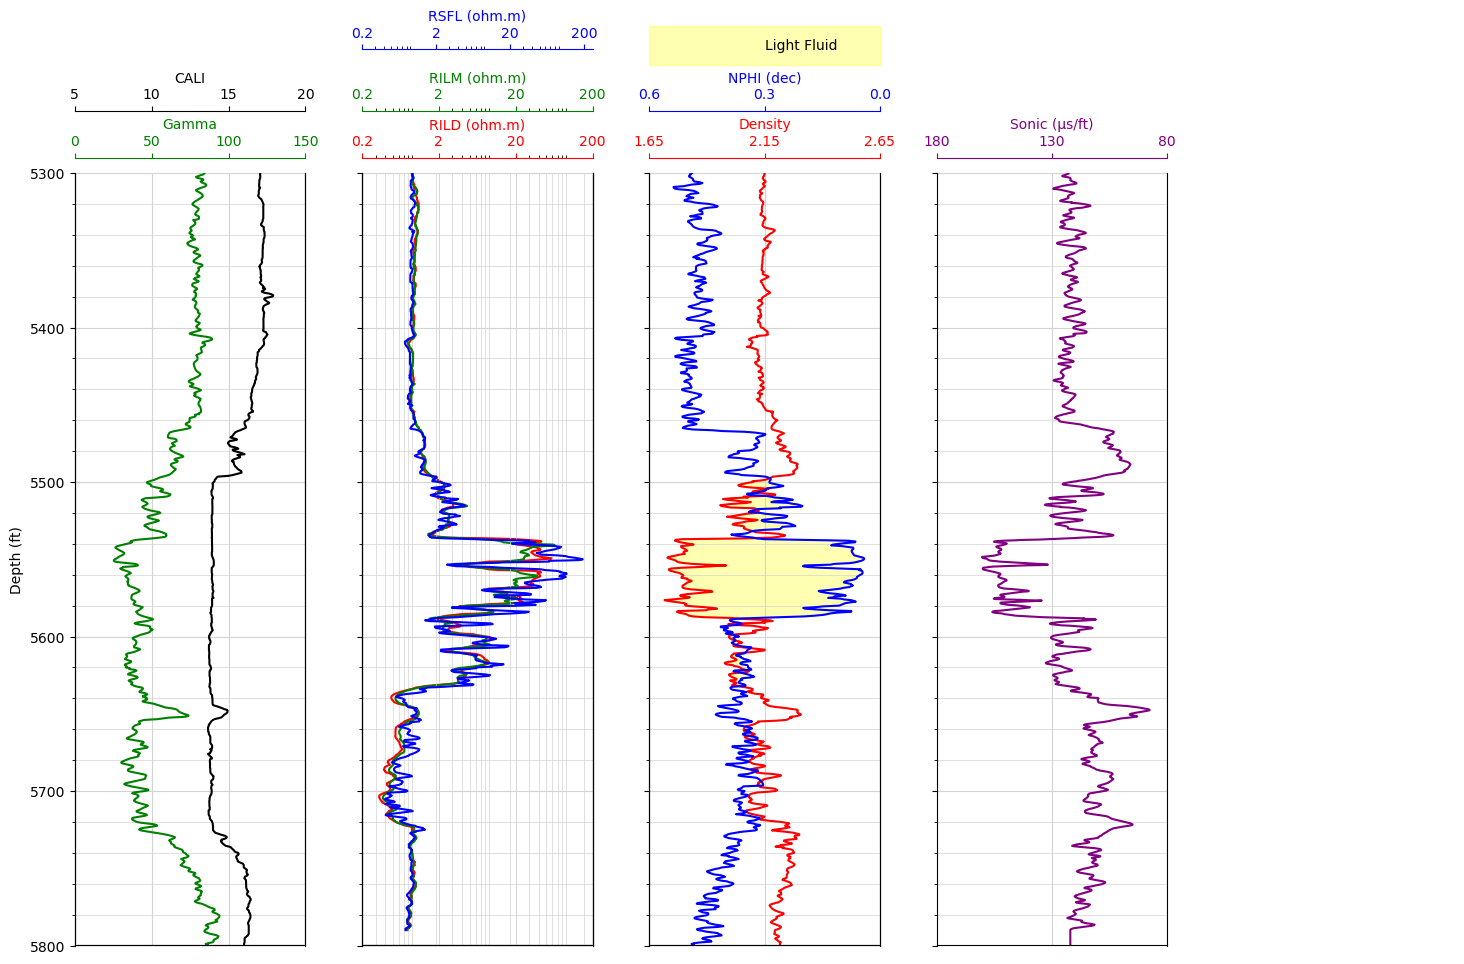

In [37]:

# This assumes that df2 has the data from the logs
fig, ax = plt.subplots(figsize=(15, 10), sharey=True)
fig.patch.set_visible(False)
plt.axis('off')

# Set up the plot axes
ax1 = plt.subplot2grid((1, 5), (0, 0), rowspan=1, colspan=1)
ax2 = plt.subplot2grid((1, 5), (0, 1), rowspan=1, colspan=1)
ax3 = plt.subplot2grid((1, 5), (0, 2), rowspan=1, colspan=1)
ax4 = plt.subplot2grid((1, 5), (0, 3), rowspan=1, colspan=1)
ax5 = ax3.twiny()  # Twins the y-axis for the density track with the neutron track

# Set common y-limits (Depth limits) for all subplots
common_ylim = (5300, 5800) 

# Gamma Ray track
ax1.plot("GR", "DEPTH", data=df2, color="green")
ax1.set_xlabel("Gamma") # Alias or name for the header of the track
ax1.xaxis.label.set_color("green") # color for the label
ax1.set_xlim(0, 150) # limit for GR axes
ax1.set_ylabel("Depth (ft)") # This is the only track that will show this
ax1.tick_params(axis='x', colors="green") # thick lines
ax1.spines["top"].set_edgecolor("green") 
ax1.title.set_color('green') # color for curve title
ax1.set_xticks([0, 50, 100, 150]) # tick lines for GR axes
ax1.set_ylim(common_ylim)

ax1_twiny = ax1.twiny()
ax1_twiny.plot("CALI_inches", "DEPTH", data=df2, color="black", label="CALI")
ax1_twiny.set_xlabel("CALI")
ax1_twiny.xaxis.label.set_color("black")
ax1_twiny.set_xlim(5, 20)  # Limit CALI to 0-20
ax1_twiny.tick_params(axis='x', colors="black")
ax1_twiny.spines["top"].set_position(("axes", 1.08))
ax1_twiny.spines["top"].set_edgecolor("black")


# Resistivity track
# Deep resistivity
ax2.plot("RILD", "DEPTH", data=df2, color="red")  # Deep resistivity
ax2.set_xlabel("RILD (ohm.m)")
ax2.set_xlim(0.2, 200)
ax2.xaxis.label.set_color("red")
ax2.tick_params(axis='x', colors="red")
ax2.spines["top"].set_edgecolor("red")
ax2.semilogx()
ax2.set_ylim(common_ylim)
ax2.grid(which='both', axis='x', color='lightgrey', linestyle='-', linewidth=0.5)

# create a twin axis for shallow resistivity
ax2_twiny1 = ax2.twiny()
ax2_twiny1.plot("RILM", "DEPTH", data=df2, color="green")  # Medium resistivity
ax2_twiny1.set_xlabel("RILM (ohm.m)")
ax2_twiny1.xaxis.label.set_color("green")
ax2_twiny1.tick_params(axis='x', colors="green")
ax2_twiny1.spines["top"].set_position(("axes", 1.08))
ax2_twiny1.spines["top"].set_edgecolor("green")
ax2_twiny1.semilogx()
ax2_twiny1.set_ylim(common_ylim)

# create a twin axis for spherically-focused resistivity
ax2_twiny2 = ax2.twiny()
ax2_twiny2.plot("RSFL", "DEPTH", data=df2, color="blue")  # Spherical resistivity
ax2_twiny2.set_xlabel("RSFL (ohm.m)")
ax2_twiny2.xaxis.label.set_color("blue")
ax2_twiny2.tick_params(axis='x', colors="blue")
ax2_twiny2.spines["top"].set_position(("axes", 1.16))
ax2_twiny2.spines["top"].set_edgecolor("blue")
ax2_twiny2.semilogx()
ax2_twiny2.set_ylim(common_ylim)

# Density track
ax3.plot("RHOB", "DEPTH", data=df2, color="red")
ax3.set_xlabel("Density")
ax3.set_xlim(1.65, 2.65)
ax3.xaxis.label.set_color("red")
ax3.tick_params(axis='x', colors="red")
ax3.spines["top"].set_edgecolor("red")
ax3.set_xticks([1.65, 2.15, 2.65])
ax3.set_ylim(common_ylim)


# Sonic track
ax4.plot("DT", "DEPTH", data=df2, color="purple")
ax4.set_xlabel("Sonic (µs/ft)")
ax4.set_xlim(180, 80)
ax4.xaxis.label.set_color("purple")
ax4.tick_params(axis='x', colors="purple")
ax4.spines["top"].set_edgecolor("purple")
ax4.set_ylim(common_ylim)
ax4.set_xticks([180,130,80])
ax4.set_xticklabels([180,130,80])  # Ensure labels match the ticks

# Neutron track placed on top of density track
ax5.plot("NPHI_SS", "DEPTH", data=df2, color="blue")
ax5.set_xlabel('NPHI (dec)')
ax5.xaxis.label.set_color("blue")
ax5.set_xlim(0.6, 0)
ax5.set_ylim(common_ylim)
ax5.tick_params(axis='x', colors="blue")
ax5.spines["top"].set_position(("axes", 1.08))
ax5.spines["top"].set_visible(True)
ax5.spines["top"].set_edgecolor("blue")
ax5.set_xticks([0.6, 0.3, 0])

# Steps needed to shade
# Transform NPHI_SS data from ax5 to ax3's coordinate system
nphi_display = ax5.transData.transform(np.c_[df2["NPHI_SS"], df2["DEPTH"]])
nphi_data = ax3.transData.inverted().transform(nphi_display)

# Shading between RHOB and transformed NPHI_SS
ax3.fill_betweenx(df2["DEPTH"], df2["RHOB"], nphi_data[:, 0], where=(df2["RHOB"] < nphi_data[:, 0]), color='yellow', alpha=0.3)


# Add a rectangle with text above the NPHI label
rect = patches.Rectangle((0, 1.14), 1, 0.05, transform=ax5.transAxes, color='yellow', alpha=0.3, clip_on=False)
ax5.add_patch(rect)
ax5.text(0.5, 1.165, 'Light Fluid', transform=ax5.transAxes, fontsize=10, verticalalignment='center', color='black')


# Remove y-axis tick labels for all axes except ax1
for ax in [ax2, ax3, ax4]:
    ax.set_yticklabels([])

# Common functions for setting up the plot
for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(which='major', color='lightgrey', linestyle='-')
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.spines["top"].set_position(("axes", 1.02))


# List of all resistivity-related axes
resistivity_axes = [ax2, ax2_twiny1, ax2_twiny2]

# Set specific x-ticks and add gridlines for all resistivity-related axes
resistivity_ticks = [0.2, 2, 20, 200]
for ax in resistivity_axes:
    ax.set_xticks(resistivity_ticks)
    ax.set_xticklabels(resistivity_ticks)  # Ensure labels match the ticks
    ax.grid(which='major', axis='x', color='lightgrey', linestyle='-', linewidth=0.5)

# List of all axes including twinned axes
all_axes = [ax1, ax2, ax3, ax4,   ax2_twiny1, ax2_twiny2]


# Invert the y-axis for all axes
for ax in all_axes:
    ax.yaxis.set_minor_locator(MultipleLocator(20)) # y axes gridlines location
    ax.grid(which='minor', axis='y', color='lightgrey', linestyle='-', linewidth=0.5)
    ax.tick_params(axis='y', which='minor', labelleft=False)  # Hide minor tick labels 
    ax.invert_yaxis()



# Adjust layout
plt.tight_layout(pad=2.0)
plt.show()

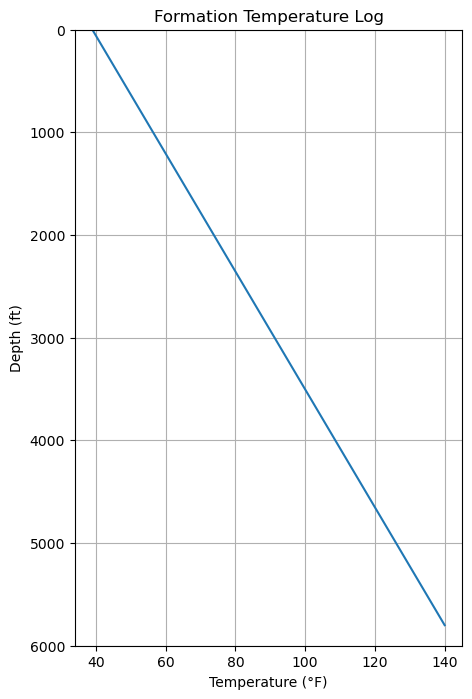

In [131]:
import numpy as np
import matplotlib.pyplot as plt

# Given data (change these values as needed)
T_s = 39  # Surface temperature in °C
T_bht = 140  # Bottom-hole temperature in °C
D_bht = 5800  # Bottom-hole depth in meters

# Calculate the geothermal gradient
G = (T_bht - T_s) / D_bht

min_depth = depths.min()
max_depth = depths.max()

# Generate depth values
depths = np.linspace(0, D_bht, 100)  # 100 points from surface to bottom-hole
temperatures = T_s + G * depths  # Compute temperatures at each depth

# Plot the formation temperature log
plt.figure(figsize=(5, 8))
plt.plot(temperatures, depths, label="Formation Temperature")
plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("Temperature (°F)")
plt.ylabel("Depth (ft)")
plt.ylim(6000, 0)
plt.title("Formation Temperature Log")
plt.grid()
plt.show()


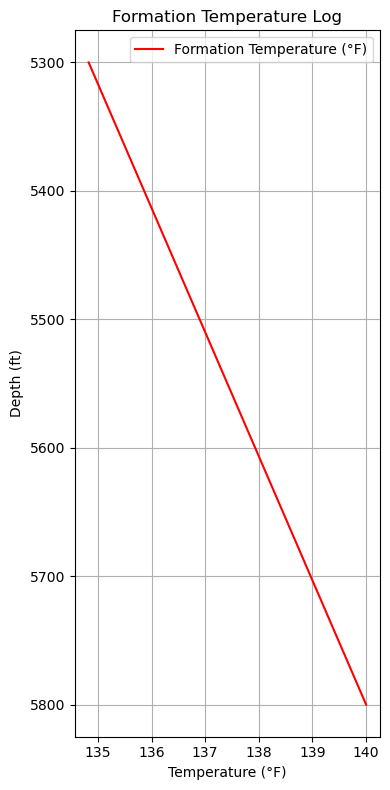

In [315]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Provided data
T_surface = 80  # Surface temperature in °F
T_bottom = 140  # Bottom-hole temperature in °F
D_bottom = 5800  # Total depth in ft

# Calculate the geothermal gradient (G)
G = (T_bottom - T_surface) / D_bottom

# Calculate formation temperature (T) for each depth
df["TEMP"] = T_surface + G * df["DEPTH"]

# Step 2: Plot the formation temperature log
plt.figure(figsize=(4, 8))

# Plot the formation temperature log
plt.plot(df["TEMP"], df["DEPTH"], color="red", label="Formation Temperature (°F)")

# Add labels, legend, and grid
plt.xlabel("Temperature (°F)")
plt.ylabel("Depth (ft)")
plt.title("Formation Temperature Log")
plt.legend(loc="upper right")
plt.grid(True)
plt.gca().invert_yaxis()  # Invert depth axis

# Show the plot
plt.tight_layout()
plt.show()

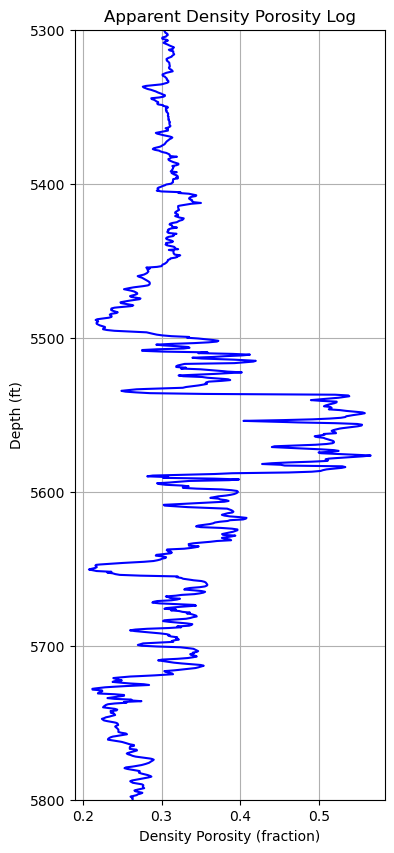

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load real density log data from Excel
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Ensure the file is in the same directory


# Extract depth and bulk density columns (ensure column names match your Excel file)
depths = df["DEPTH"].values  # Replace "DEPTH" with the actual column name if different
rho_b = df["RHOB"].values  # Replace "RHOB" with the actual bulk density column name

# Given constants
rho_m = 2.65  # Quartz matrix density in g/cc
rho_f = 1.00  # Fluid density in g/cc

# Calculate apparent density porosity
phi_D = (rho_m - rho_b) / (rho_m - rho_f)

# Plot the apparent density porosity log
plt.figure(figsize=(4, 10))
plt.plot(phi_D, depths, label="Apparent Density Porosity", color="blue")
plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel("Density Porosity (fraction)")
plt.ylabel("Depth (ft)")
plt.ylim(5800, 5300)
plt.title("Apparent Density Porosity Log")
plt.grid()
plt.show()


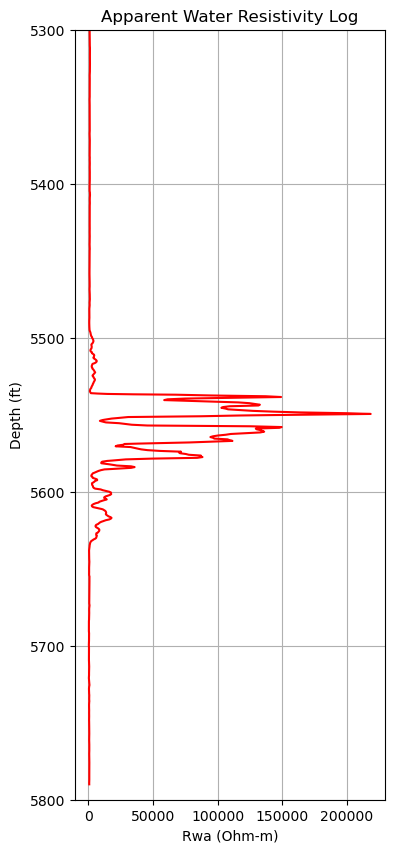

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load well log data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Replace -999.25 and any non-numeric values with NaN
df["DPHI"] = df["DPHI"].replace(-999.25, np.nan)
df["RILD"] = pd.to_numeric(df["RILD"], errors='coerce')  # Convert to numeric, invalid parsing will be NaN

# Drop rows where any of the relevant columns are NaN
df_clean = df.dropna(subset=["DPHI", "RILD"])

# Extract the cleaned data
depths = df_clean["DEPTH"].values  # Depth in ft or m
phi_D = np.array(df_clean["DPHI"].values, dtype=float)  # Convert to numpy array and decimal
Rt = np.array(df_clean["RILD"].values, dtype=float)  # Convert to numpy array

# Constants
m = 2.05  # Cementation exponent
alpha = 1  # Tortuosity factor

# Calculate apparent water resistivity (Rwa)
Rwa = Rt * (phi_D**m / alpha)

# Plot Apparent Water Resistivity Log
plt.figure(figsize=(4, 10))
plt.plot(Rwa, depths, label="Apparent Water Resistivity (Ohm-m)", color="red")

# Invert y-axis to follow well log format
plt.ylim(min(depths), max(depths))
plt.gca().invert_yaxis()

# Labels and formatting
plt.xlabel("Rwa (Ohm-m)")
plt.ylabel("Depth (ft)")
plt.title("Apparent Water Resistivity Log")
plt.grid()
plt.ylim(5800, 5300)

plt.show()


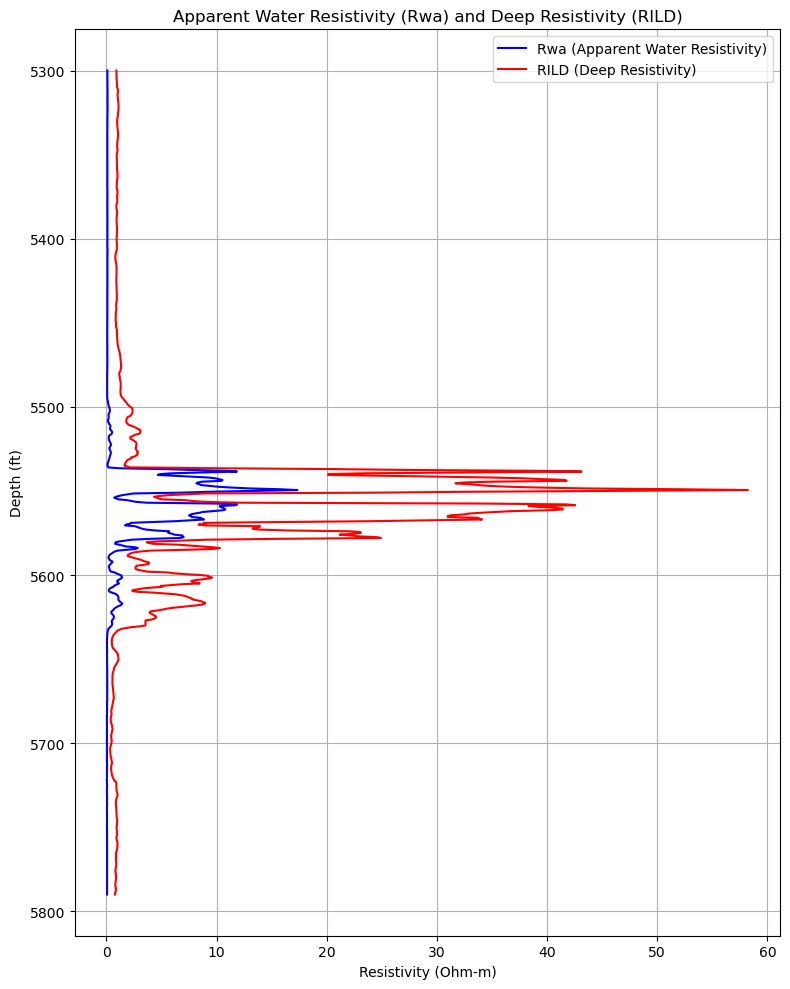

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RSFL", "RILM", "RILD", "RHOB", "NPHI (SS UNI", "GR", "CALI", "DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_fluid = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_fluid)

# Archie's equation parameters (for sandstone)
a = 1.0  # Tortuosity factor
m = 2.05  # Cementation exponent

# Calculate apparent water resistivity (Rwa)
df["Rwa"] = df["RILD"] * (df["DPHI"] ** m / a)

# Step 4: Plot the Rwa log
plt.figure(figsize=(8, 10))

# Plot the Rwa log
plt.plot(df["Rwa"], df["DEPTH"], color="blue", label="Rwa (Apparent Water Resistivity)")

# Plot the deep resistivity log (RILD) for comparison
plt.plot(df["RILD"], df["DEPTH"], color="red", label="RILD (Deep Resistivity)")

# Add labels, legend, and grid
plt.xlabel("Resistivity (Ohm-m)")
plt.ylabel("Depth (ft)")
plt.title("Apparent Water Resistivity (Rwa) and Deep Resistivity (RILD)")
plt.legend(loc="upper right")
plt.grid(True)
plt.gca().invert_yaxis()  # Invert depth axis

# Show the plot
plt.tight_layout()
plt.show()

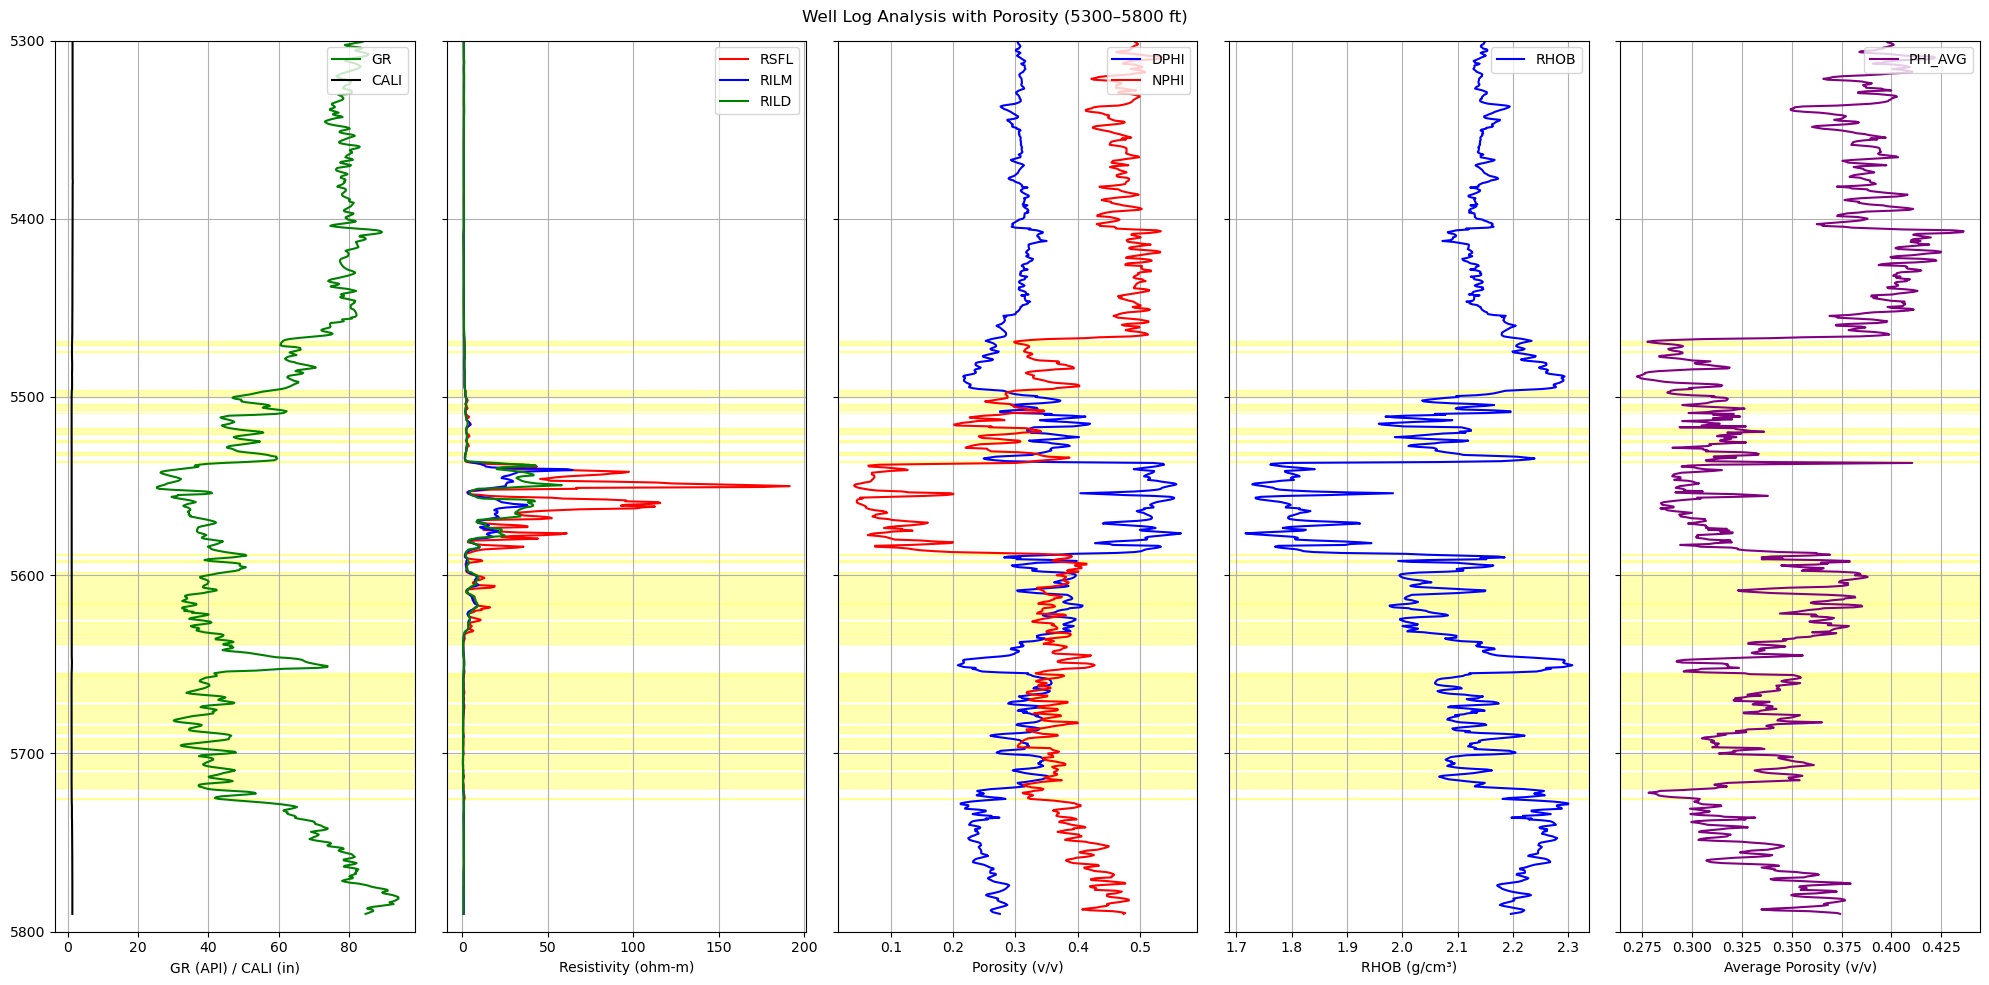

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RSFL", "RILM", "RILD", "RHOB", "NPHI (SS UNI", "GR", "CALI", "DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_fluid = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI) if not already provided
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_fluid)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Identify aquifer interval (example: GR < 75 API and DPHI ≈ NPHI)
aquifer_mask = (df["GR"] < 75) & (np.abs(df["DPHI"] - df["NPHI (SS UNI"]) < 0.05)
aquifer_data = df[aquifer_mask]

# Create the plot
fig, axes = plt.subplots(1, 5, figsize=(20, 10), sharey=True)
fig.suptitle("Well Log Analysis with Porosity (5300–5800 ft)")

# Track 1: GR and CALI
ax1 = axes[0]
ax1.plot(df["GR"], df["DEPTH"], color="green", label="GR")
ax1.plot(df["CALI"], df["DEPTH"], color="black", label="CALI")
ax1.set_xlabel("GR (API) / CALI (in)")
ax1.legend(loc="upper right")

# Track 2: Resistivity
ax2 = axes[1]
ax2.plot(df["RSFL"], df["DEPTH"], color="red", label="RSFL")
ax2.plot(df["RILM"], df["DEPTH"], color="blue", label="RILM")
ax2.plot(df["RILD"], df["DEPTH"], color="green", label="RILD")
ax2.set_xlabel("Resistivity (ohm-m)")
ax2.legend(loc="upper right")

# Track 3: Porosity (DPHI and NPHI)
ax3 = axes[2]
ax3.plot(df["DPHI"], df["DEPTH"], color="blue", label="DPHI")
ax3.plot(df["NPHI (SS UNI"], df["DEPTH"], color="red", label="NPHI")
ax3.set_xlabel("Porosity (v/v)")
ax3.legend(loc="upper right")

# Track 4: RHOB and DT
ax4 = axes[3]
ax4.plot(df["RHOB"], df["DEPTH"], color="blue", label="RHOB")
ax4.set_xlabel("RHOB (g/cm³)")
ax4.legend(loc="upper right")

# Track 5: Calculated Porosity (PHI_AVG)
ax5 = axes[4]
ax5.plot(df["PHI_AVG"], df["DEPTH"], color="purple", label="PHI_AVG")
ax5.set_xlabel("Average Porosity (v/v)")
ax5.legend(loc="upper right")

# Highlight aquifer interval
for ax in axes:
    ax.fill_betweenx(df["DEPTH"], 0, 1, where=aquifer_mask, color="yellow", alpha=0.3, transform=ax.get_yaxis_transform())

# Format the plot
for ax in axes:
    ax.set_ylim(5800, 5300)  # Invert depth axis
    ax.grid(True)

plt.tight_layout()
plt.show()

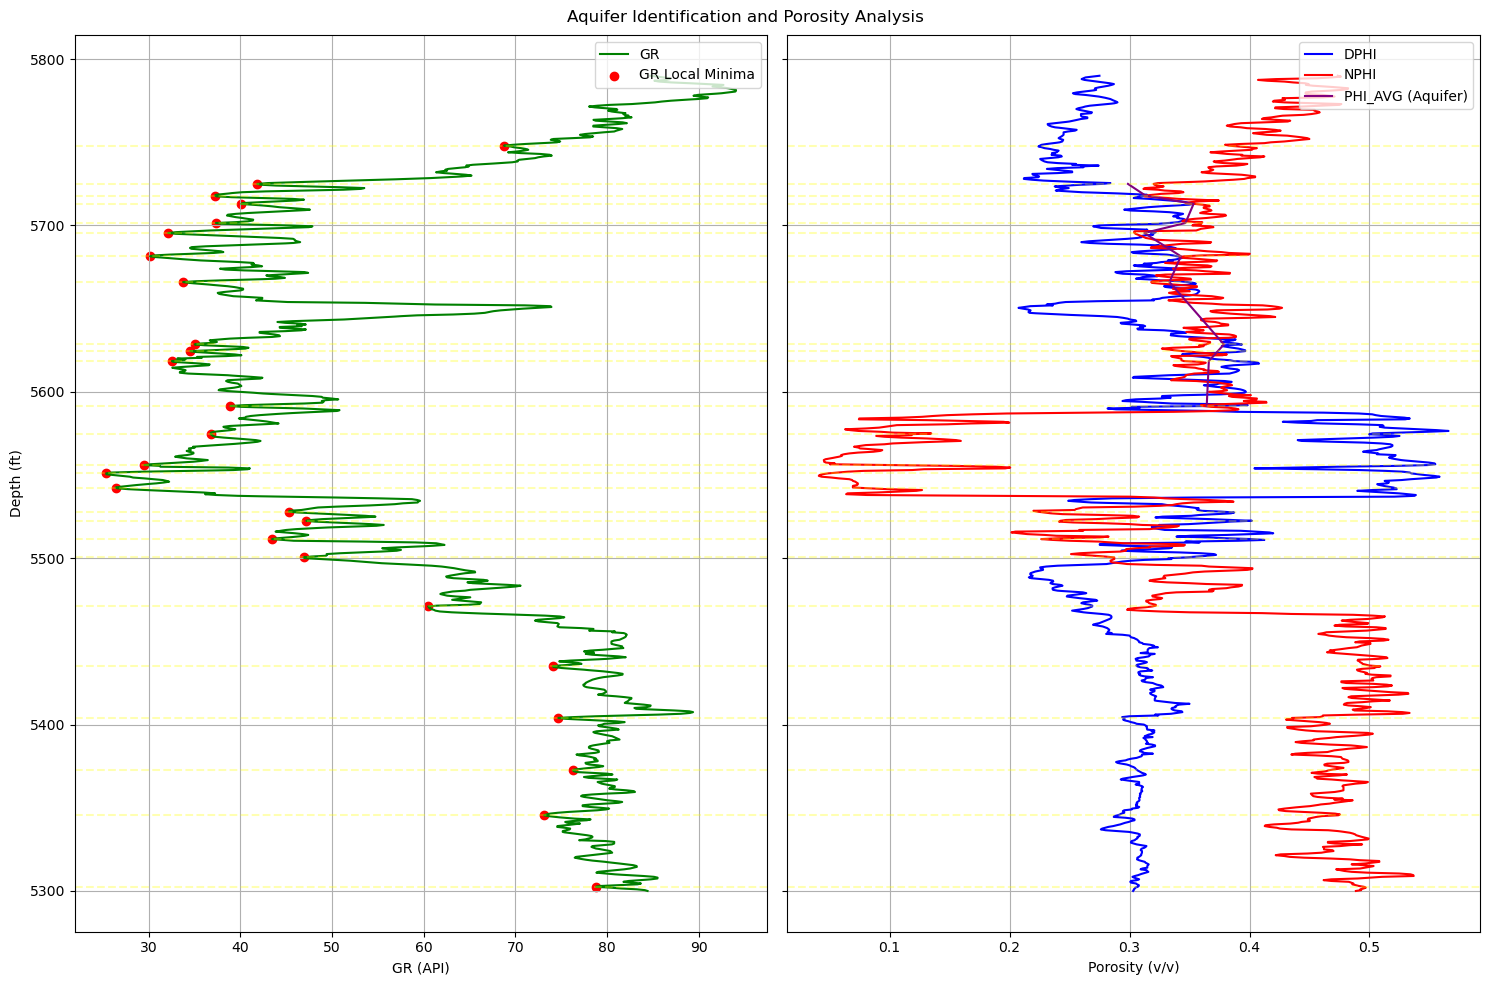

Aquifer Depth Intervals (Local Minima with DPHI ≈ NPHI):
5302.5 ft
5345.5 ft
5372.5 ft
5404.0 ft
5435.0 ft
5471.0 ft
5500.5 ft
5511.5 ft
5522.5 ft
5528.0 ft
5542.5 ft
5551.0 ft
5556.0 ft
5574.5 ft
5591.5 ft
5618.5 ft
5624.5 ft
5628.5 ft
5666.0 ft
5681.5 ft
5695.5 ft
5701.5 ft
5713.0 ft
5718.0 ft
5725.0 ft
5748.0 ft


In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RSFL", "RILM", "RILD", "RHOB", "NPHI (SS UNI", "GR", "CALI", "DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_fluid = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_fluid)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 1: Identify local minima in the GR log
# Use scipy.signal.find_peaks to find local minima (invert the GR log)
GR_inverted = -df["GR"]
peaks, _ = find_peaks(GR_inverted, prominence=5)  # Adjust prominence as needed
local_min_depths = df.iloc[peaks]["DEPTH"]

# Step 2: Verify DPHI ≈ NPHI at local minima depths
tolerance = 0.05  # Tolerance for DPHI ≈ NPHI
aquifer_mask = (
    df["DEPTH"].isin(local_min_depths) &  # GR local minima
    (np.abs(df["DPHI"] - df["NPHI (SS UNI"]) < tolerance)  # DPHI ≈ NPHI
)
aquifer_data = df[aquifer_mask]

# Step 3: Calculate and plot rock porosity
# Plot the GR log with local minima highlighted
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Aquifer Identification and Porosity Analysis")

# Track 1: GR log with local minima highlighted
ax1 = axes[0]
ax1.plot(df["GR"], df["DEPTH"], color="green", label="GR")
ax1.scatter(df.loc[peaks, "GR"], df.loc[peaks, "DEPTH"], color="red", label="GR Local Minima")
ax1.set_xlabel("GR (API)")
ax1.set_ylabel("Depth (ft)")
ax1.legend(loc="upper right")
ax1.grid(True)
ax1.invert_yaxis()  # Invert depth axis

# Track 2: Porosity logs and calculated porosity
ax2 = axes[1]
ax2.plot(df["DPHI"], df["DEPTH"], color="blue", label="DPHI")
ax2.plot(df["NPHI (SS UNI"], df["DEPTH"], color="red", label="NPHI")
ax2.plot(aquifer_data["PHI_AVG"], aquifer_data["DEPTH"], color="purple", label="PHI_AVG (Aquifer)")
ax2.set_xlabel("Porosity (v/v)")
ax2.legend(loc="upper right")
ax2.grid(True)
ax2.invert_yaxis()  # Invert depth axis

# Highlight aquifer intervals
for ax in axes:
    for depth in local_min_depths:
        ax.axhline(y=depth, color="yellow", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Print aquifer depth intervals
print("Aquifer Depth Intervals (Local Minima with DPHI ≈ NPHI):")
for depth in local_min_depths:
    print(f"{depth} ft")

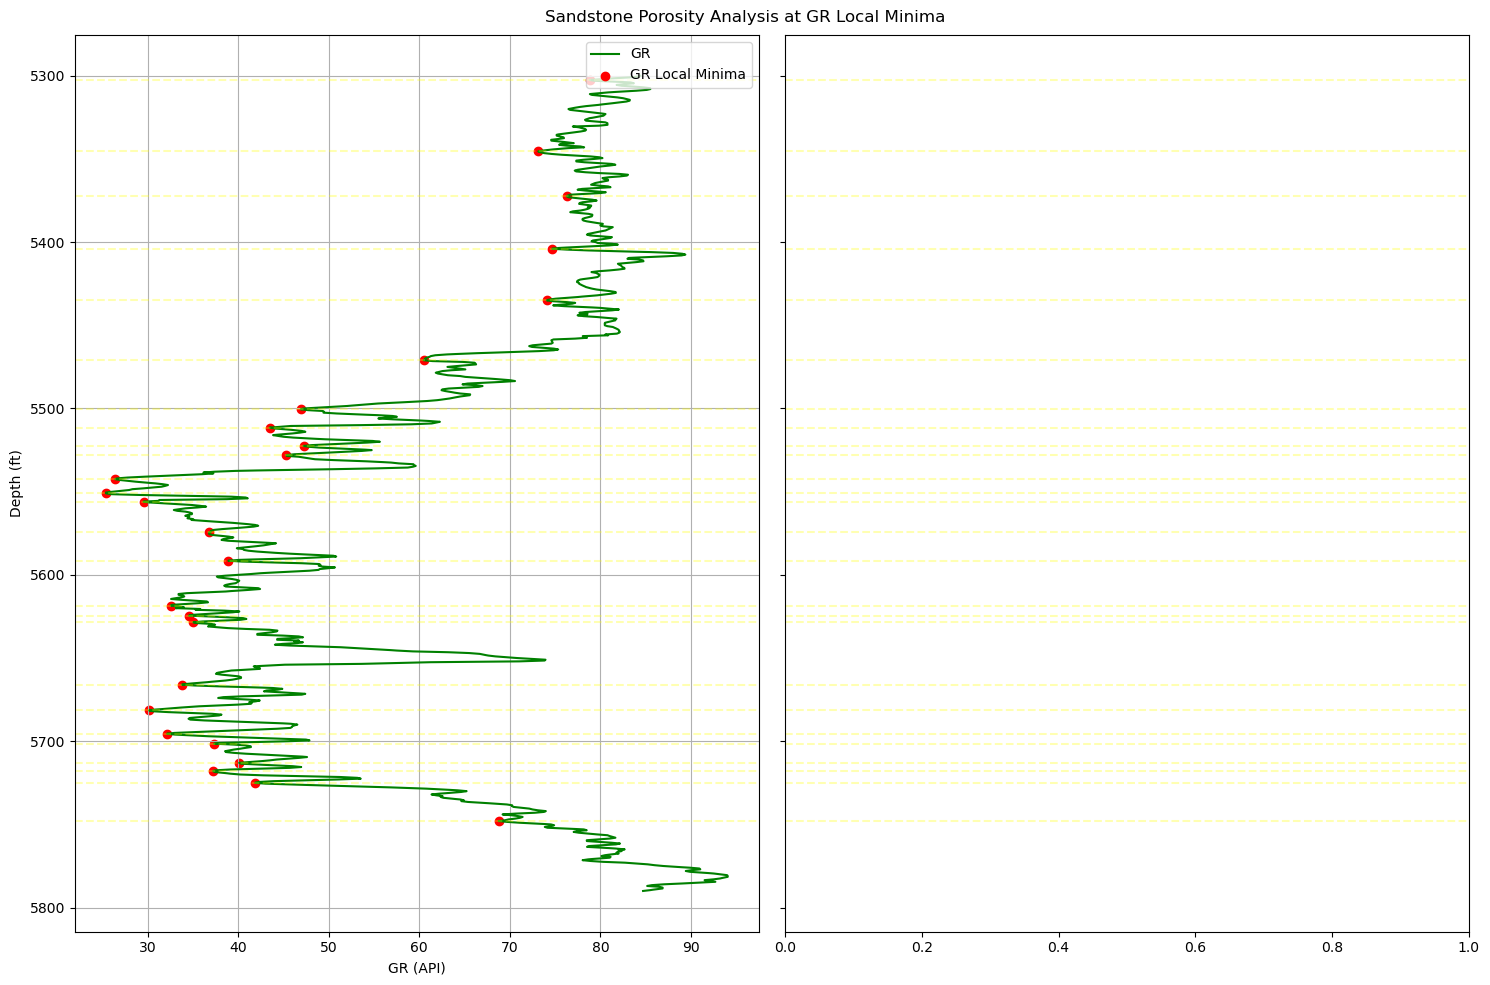

GR Local Minima
5302.5 ft
5345.5 ft
5372.5 ft
5404.0 ft
5435.0 ft
5471.0 ft
5500.5 ft
5511.5 ft
5522.5 ft
5528.0 ft
5542.5 ft
5551.0 ft
5556.0 ft
5574.5 ft
5591.5 ft
5618.5 ft
5624.5 ft
5628.5 ft
5666.0 ft
5681.5 ft
5695.5 ft
5701.5 ft
5713.0 ft
5718.0 ft
5725.0 ft
5748.0 ft


In [351]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RSFL", "RILM", "RILD", "RHOB", "NPHI (SS UNI", "GR", "CALI", "DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_fluid = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_fluid)

# Step 1: Identify local minima in the GR log
# Use scipy.signal.find_peaks to find local minima (invert the GR log)
GR_inverted = -df["GR"]
peaks, _ = find_peaks(GR_inverted, prominence=5)  # Adjust prominence as needed
local_min_depths = df.iloc[peaks]["DEPTH"]

# Step 2: Calculate sandstone porosity at local minima depths
# Using the provided formula for porosity
df["SANDSTONE_PHI"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 3: Filter sandstone porosity for clean sandstones based on GR minima
sandstone_porosity_data = df[df["DEPTH"].isin(local_min_depths)]

# Plot the GR log and calculated sandstone porosity at local minima depths
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Sandstone Porosity Analysis at GR Local Minima")

# Track 1: GR log with local minima highlighted
ax1 = axes[0]
ax1.plot(df["GR"], df["DEPTH"], color="green", label="GR")
ax1.scatter(df.loc[peaks, "GR"], df.loc[peaks, "DEPTH"], color="red", label="GR Local Minima")
ax1.set_xlabel("GR (API)")
ax1.set_ylabel("Depth (ft)")
ax1.legend(loc="upper right")
ax1.grid(True)
ax1.invert_yaxis()  # Invert depth axis

# Highlight sandstone intervals
for ax in axes:
    for depth in local_min_depths:
        ax.axhline(y=depth, color="yellow", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


# Step 2: Print all depths where the GR log has a local minimum
import builtins
builtins.print("GR Local Minima")
for depth in local_min_depths:
    builtins.print(f"{depth} ft")


In [183]:
# Example: Calculate thickness for the first interval
start_depth = 5302.5
end_depth = 5345.5
thickness = end_depth - start_depth
print(f"Thickness: {thickness} ft")

# Example: Calculate average porosity for the first interval
interval_data = df[(df["DEPTH"] >= start_depth) & (df["DEPTH"] <= end_depth)]
average_porosity = interval_data["PHI_AVG"].mean()
print(f"Average Porosity: {average_porosity:.2f} v/v")

Thickness: 43.0 ft
Average Porosity: 0.39 v/v


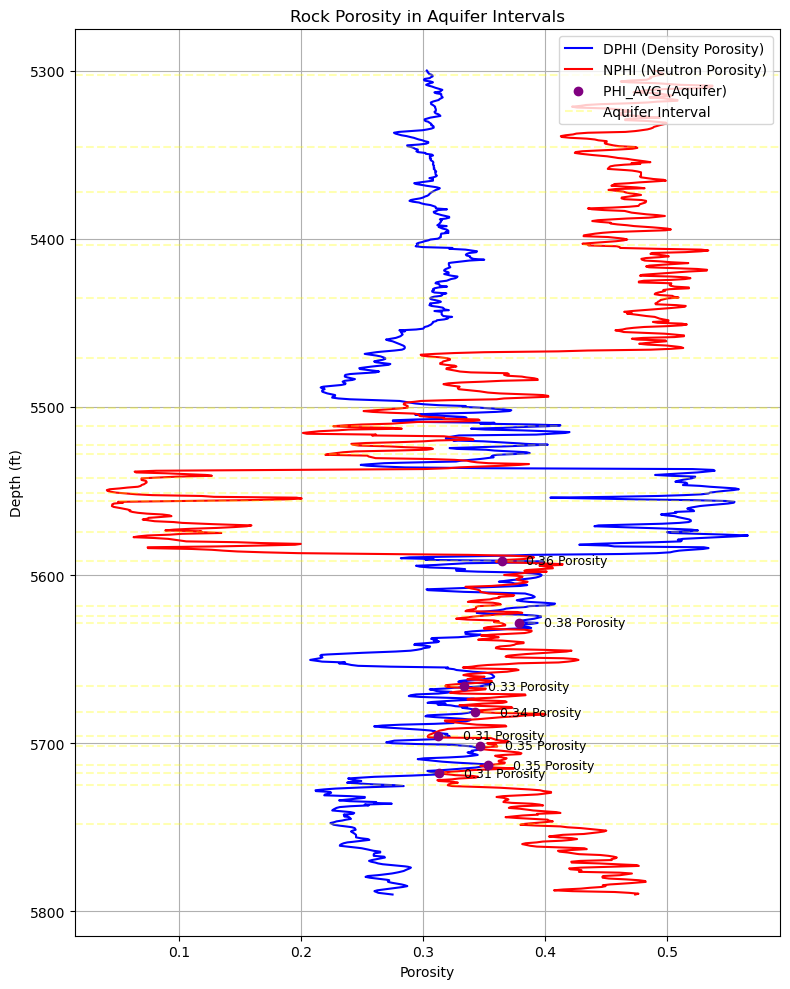

PHI_AVG
5302.5 ft
5345.5 ft
5372.5 ft
5404.0 ft
5435.0 ft
5471.0 ft
5500.5 ft
5511.5 ft
5522.5 ft
5528.0 ft
5542.5 ft
5551.0 ft
5556.0 ft
5574.5 ft
5591.5 ft
5618.5 ft
5624.5 ft
5628.5 ft
5666.0 ft
5681.5 ft
5695.5 ft
5701.5 ft
5713.0 ft
5718.0 ft
5725.0 ft
5748.0 ft


In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RSFL", "RILM", "RILD", "RHOB", "NPHI (SS UNI", "GR", "CALI", "DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_fluid = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_fluid)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 1: Identify local minima in the GR log
# Use scipy.signal.find_peaks to find local minima (invert the GR log)
GR_inverted = -df["GR"]
peaks, _ = find_peaks(GR_inverted, prominence=5)  # Adjust prominence as needed
local_min_depths = df.iloc[peaks]["DEPTH"].tolist()  # Convert to list for easier indexing

# Step 2: Verify DPHI ≈ NPHI at local minima depths
tolerance = 0.04  # Tolerance for DPHI ≈ NPHI
aquifer_mask = (
    df["DEPTH"].isin(local_min_depths) &  # GR local minima
    (np.abs(df["DPHI"] - df["NPHI (SS UNI"]) < tolerance)  # DPHI ≈ NPHI
)
aquifer_data = df[aquifer_mask]

# Extract porosity and depth values for aquifer intervals
aquifer_porosities = aquifer_data["PHI_AVG"]
aquifer_depths = aquifer_data["DEPTH"]

# Step 3: Plot the porosity values
plt.figure(figsize=(8, 10))

# Plot the porosity logs for the entire depth range
plt.plot(df["DPHI"], df["DEPTH"], color="blue", label="DPHI (Density Porosity)")
plt.plot(df["NPHI (SS UNI"], df["DEPTH"], color="red", label="NPHI (Neutron Porosity)")

# Plot the average porosity for the aquifer intervals
plt.scatter(aquifer_porosities, aquifer_depths, color="purple", label="PHI_AVG (Aquifer)", zorder=5)

# Highlight the aquifer intervals
for depth in local_min_depths:
    plt.axhline(y=depth, color="yellow", alpha=0.3, linestyle="--", label="Aquifer Interval" if depth == local_min_depths[0] else "")

# Annotate the aquifer intervals with depth and porosity
for depth, porosity in zip(aquifer_depths, aquifer_porosities):
    plt.text(
        x=porosity + 0.02,  # X position of the annotation (slightly offset from the point)
        y=depth,  # Y position (depth)
        s=f"{porosity:.2f} Porosity",  # Text to display (depth and porosity)
        color="black",  # Text color
        fontsize=9,  # Font size
        verticalalignment="center",  # Align text vertically
    )

# Add labels, legend, and grid
plt.xlabel("Porosity")
plt.ylabel("Depth (ft)")
plt.title("Rock Porosity in Aquifer Intervals")
plt.legend(loc="upper right")
plt.grid(True)
plt.gca().invert_yaxis()  # Invert depth axis

# Show the plot
plt.tight_layout()
plt.show()

import builtins
builtins.print("PHI_AVG")
for depth in local_min_depths:
    builtins.print(f"{depth} ft")

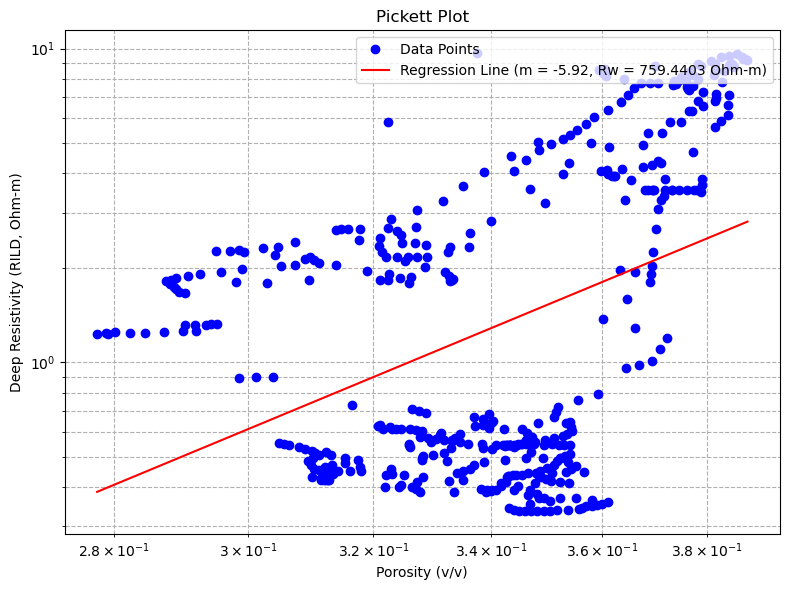

Archie's m exponent: -5.92
Formation water resistivity (Rw): 759.4403 Ohm-m
Salinity: 5.17 ppm NaCl


In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RILD", "RHOB", "NPHI (SS UNI", "DEPTH", "GR", "SP", "RWA", "RSFL", "RILM"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Step 1: Handle invalid values in resistivity and SP logs
# Replace or remove rows with invalid values (e.g., -9999, 0000)
invalid_values = [-9999, 0]  # Define invalid values
for col in ["RILD", "RSFL", "RILM", "SP", "RWA"]:
    df = df[~df[col].isin(invalid_values)]  # Remove rows with invalid values

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_f = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_f)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 2: Extract data for the aquifer interval
# Use stricter criteria to ensure clean, water-bearing zones
aquifer_mask = (
    (df["GR"] < 75) &  # Low GR (clean formation)
    (df["RILD"] < 100) &  # Low resistivity (water-bearing)
    (np.abs(df["DPHI"] - df["NPHI (SS UNI"]) < 0.05) &  # DPHI ≈ NPHI
    (df["PHI_AVG"] > 0.05) & (df["PHI_AVG"] < 0.4)  # Reasonable porosity range
)
aquifer_data = df[aquifer_mask]

# Extract porosity and deep resistivity for the aquifer interval
phi = aquifer_data["PHI_AVG"]
Rt = aquifer_data["RILD"]

# Remove outliers (e.g., resistivity < 0.1 Ohm-m or porosity > 0.4)
outlier_mask = (Rt > 0.1) & (Rt < 100) & (phi > 0.05) & (phi < 0.4)
phi = phi[outlier_mask]
Rt = Rt[outlier_mask]

# Step 3: Construct the Pickett plot
plt.figure(figsize=(8, 6))
plt.loglog(phi, Rt, "bo", label="Data Points")
plt.xlabel("Porosity (v/v)")
plt.ylabel("Deep Resistivity (RILD, Ohm-m)")
plt.title("Pickett Plot")
plt.grid(True, which="both", linestyle="--")

# Step 4: Perform linear regression on log-transformed data
log_phi = np.log10(phi)
log_Rt = np.log10(Rt)
slope, intercept, r_value, p_value, std_err = linregress(log_phi, log_Rt)

# Step 5: Estimate Archie's m and Rw
m = -slope  # Archie's cementation exponent
a = 1.0  # Tortuosity factor (assumed for sandstones)
log_aRw = intercept
Rw = 10**log_aRw / a  # Formation water resistivity

# Step 6: Plot the regression line
phi_fit = np.logspace(np.log10(phi.min()), np.log10(phi.max()), 100)
Rt_fit = 10**(intercept + slope * np.log10(phi_fit))
plt.loglog(phi_fit, Rt_fit, "r-", label=f"Regression Line (m = {m:.2f}, Rw = {Rw:.4f} Ohm-m)")
plt.legend(loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

# Step 7: Calculate salinity in NaCl ppm
# Use the empirical relationship: R_w = 0.0123 + (3647.5 / salinity)^0.955
if Rw > 0.0123:  # Ensure Rw is valid for the salinity calculation
    salinity = (3647.5 / (Rw - 0.0123))**(1 / 0.955)
else:
    salinity = np.nan  # Invalid Rw

# Print results
print(f"Archie's m exponent: {m:.2f}")
print(f"Formation water resistivity (Rw): {Rw:.4f} Ohm-m")
print(f"Salinity: {salinity:.2f} ppm NaCl")

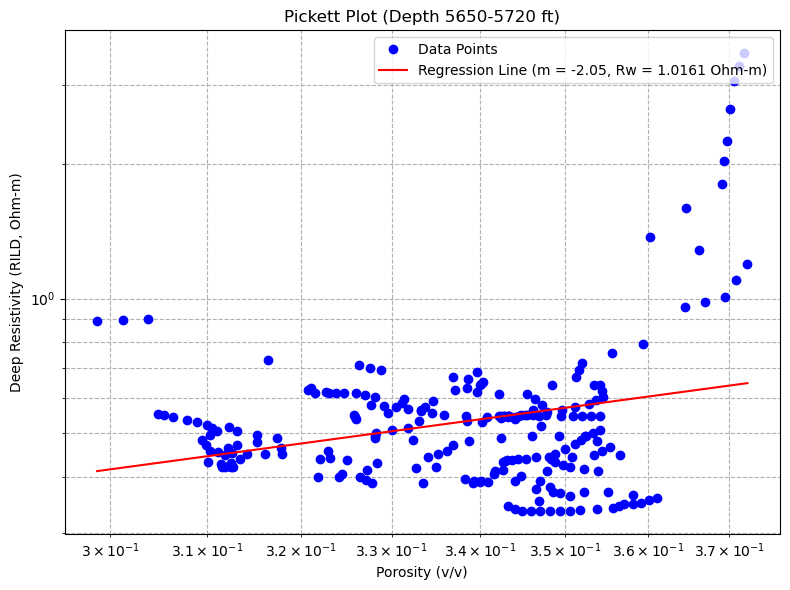

Archie's m exponent: -2.05
Formation water resistivity (Rw): 1.0161 Ohm-m
Salinity: 5347.22 ppm NaCl


In [445]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RILD", "RHOB", "NPHI (SS UNI", "DEPTH", "GR", "SP", "RWA", "RSFL", "RILM"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Step 1: Filter data for the specified depth range
df = df[(df["DEPTH"] >= 5630) & (df["DEPTH"] <= 5780)]

# Step 2: Handle invalid values in resistivity and SP logs
invalid_values = [-9999, 0000]  # Define invalid values
for col in ["RILD", "RSFL", "RILM", "SP", "RWA"]:
    df = df[~df[col].isin(invalid_values)]  # Remove rows with invalid values

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_f = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_f)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 3: Extract data for the aquifer interval
aquifer_mask = (
    (df["GR"] < 75) &  # Low GR (clean formation)
    (df["RILD"] < 100) &  # Low resistivity (water-bearing)
    (np.abs(df["DPHI"] - df["NPHI (SS UNI"]) < 0.05) &  # DPHI ≈ NPHI
    (df["PHI_AVG"] > 0.1) & (df["PHI_AVG"] < 0.4)  # Reasonable porosity range
)
aquifer_data = df[aquifer_mask]

# Extract porosity and deep resistivity for the aquifer interval
phi = aquifer_data["PHI_AVG"]
Rt = aquifer_data["RILD"]

# Remove outliers (e.g., resistivity < 0.1 Ohm-m or porosity > 0.4)
outlier_mask = (Rt > 0.1) & (Rt < 100) & (phi > 0.05) & (phi < 0.4)
phi = phi[outlier_mask]
Rt = Rt[outlier_mask]

# Step 4: Construct the Pickett plot
plt.figure(figsize=(8, 6))
plt.loglog(phi, Rt, "bo", label="Data Points")
plt.xlabel("Porosity (v/v)")
plt.ylabel("Deep Resistivity (RILD, Ohm-m)")
plt.title("Pickett Plot (Depth 5650-5720 ft)")
plt.grid(True, which="both", linestyle="--")

# Step 5: Perform linear regression on log-transformed data
log_phi = np.log10(phi)
log_Rt = np.log10(Rt)
slope, intercept, r_value, p_value, std_err = linregress(log_phi, log_Rt)

# Step 6: Estimate Archie's m and Rw
m = -slope  # Archie's cementation exponent
a = 1.0  # Tortuosity factor (assumed for sandstones)
log_aRw = intercept /100
Rw = 10**log_aRw / a  # Formation water resistivity

# Step 7: Plot the regression line
phi_fit = np.logspace(np.log10(phi.min()), np.log10(phi.max()), 100)
Rt_fit = 10**(intercept + slope * np.log10(phi_fit))
plt.loglog(phi_fit, Rt_fit, "r-", label=f"Regression Line (m = {m:.2f}, Rw = {Rw:.4f} Ohm-m)")
plt.legend(loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

# Step 8: Calculate salinity in NaCl ppm
if Rw > 0.0123:  # Ensure Rw is valid for the salinity calculation
    salinity = (3647.5 / (Rw - 0.0123))**(1 / 0.955)
else:
    salinity = np.nan  # Invalid Rw

# Print results
print(f"Archie's m exponent: {m:.2f}")
print(f"Formation water resistivity (Rw): {Rw:.4f} Ohm-m")
print(f"Salinity: {salinity:.2f} ppm NaCl")


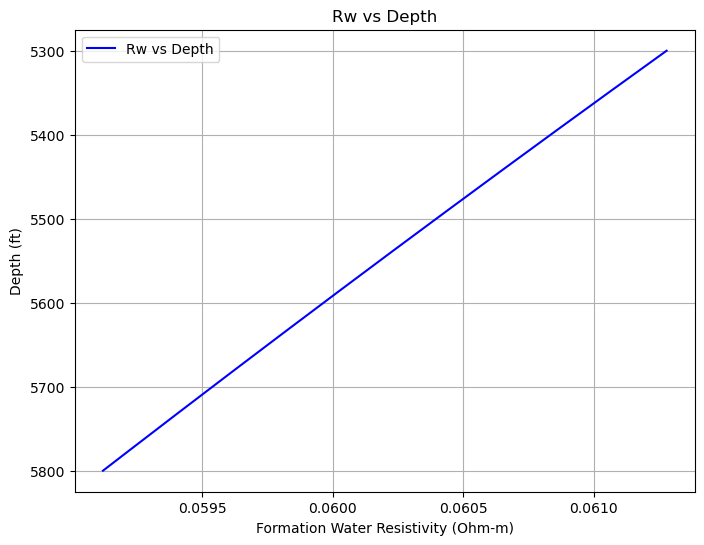

In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["DEPTH", "FORMATION TEMPERATURE"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define parameters for Rw calculation
T_surface = 80  # Surface temperature in °F
T_bottom = 140  # Bottom-hole temperature in °F
D_bottom = 5800  # Total depth in ft
G = (T_bottom - T_surface) / D_bottom  # Geothermal gradient

# Calculate formation temperature (T) for each depth
df["FORMATION TEMP"] = T_surface + G * df["DEPTH"]

# Assume a reference Rw at surface
Rw_surface = 0.1  # Example surface water resistivity (Ohm-m)

# Calculate Rw at all depths
df["RW_DEPTH"] = Rw_surface * ((T_surface + 6.77) / (df["FORMATION TEMP"] + 6.77))

# Plot Rw vs Depth
plt.figure(figsize=(8, 6))
plt.plot(df["RW_DEPTH"], df["DEPTH"], "b-", label="Rw vs Depth")
plt.xlabel("Formation Water Resistivity (Ohm-m)")
plt.ylabel("Depth (ft)")
plt.gca().invert_yaxis()
plt.title("Rw vs Depth")
plt.legend()
plt.grid()
plt.show()


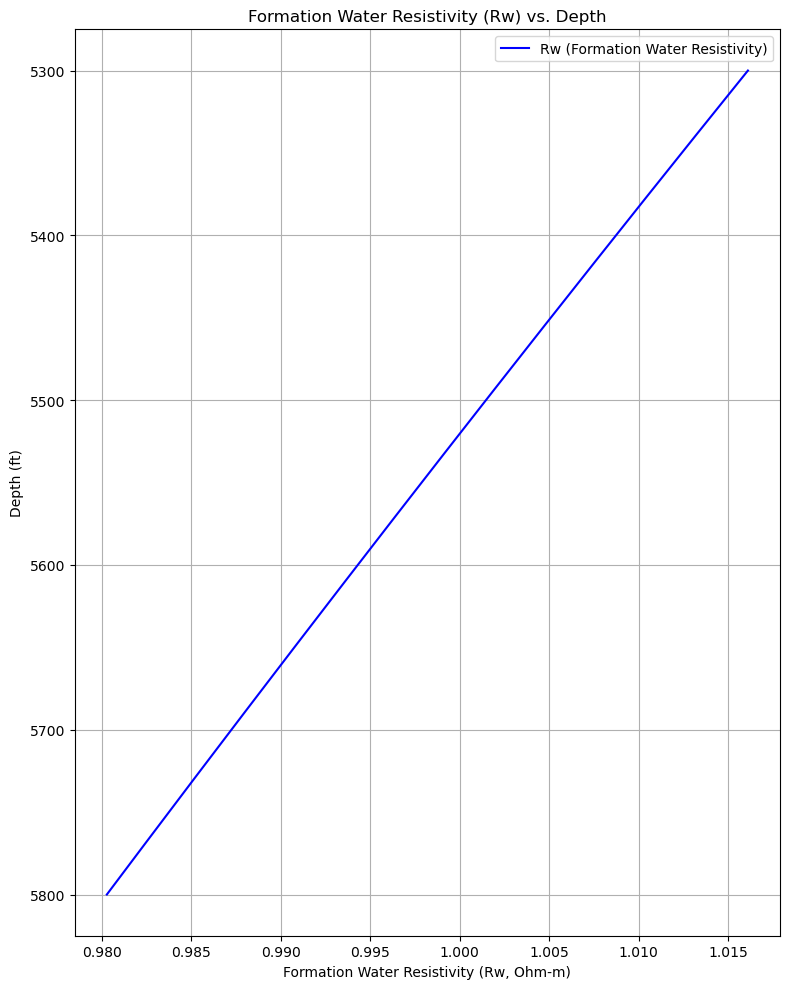

In [447]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["DEPTH"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Provided data
T_surface = 80  # Surface temperature in °F
T_bottom = 140  # Bottom-hole temperature in °F
D_bottom = 5800  # Total depth in ft

# Calculate the geothermal gradient (G)
G = (T_bottom - T_surface) / D_bottom

# Calculate formation temperature (T) for each depth
df["TEMP"] = T_surface + G * df["DEPTH"]

# Step 1: Calculate Rw at all depths
# Assume Rw_ref is the formation water resistivity at a reference temperature (e.g., 75°F)
Rw_ref = 1.0161  # Example value (replace with your calculated Rw from the Pickett plot)
T_ref = 134.82795  # Reference temperature in °F

# Calculate Rw using the temperature correction formula
df["Rw"] = Rw_ref * (T_ref + 6.77) / (df["TEMP"] + 6.77)

# Step 2: Plot Rw vs. Depth
plt.figure(figsize=(8, 10))

# Plot Rw vs. Depth
plt.plot(df["Rw"], df["DEPTH"], color="blue", label="Rw (Formation Water Resistivity)")

# Add labels, legend, and grid
plt.xlabel("Formation Water Resistivity (Rw, Ohm-m)")
plt.ylabel("Depth (ft)")
plt.title("Formation Water Resistivity (Rw) vs. Depth")
plt.legend(loc="upper right")
plt.grid(True)
plt.gca().invert_yaxis()  # Invert depth axis

# Show the plot
plt.tight_layout()
plt.show()

In [463]:
# Step 1: Calculate the density and neutron porosities (if not already done)
# DPHI (density porosity) has already been calculated as shown earlier
# Assuming NPHI is available in your dataset as 'NPHI (SS UNI)'

# Step 2: Calculate the sandstone porosity at depths where GR has local minima
df["PHI_SANDSTONE"] = np.sqrt((df["DPHI"]**2 + df["NPHI (SS UNI"]**2) / 2)

# Step 3: Filter data based on GR local minima depths
sandstone_porosity_data = df[df["DEPTH"].isin(local_min_depths)]

# Step 4: Plot the GR log, Neutron and Density Porosities, and Sandstone Porosity
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
fig.suptitle("Sandstone Porosity Analysis at GR Local Minima")

# Track 1: GR log with local minima highlighted
ax1 = axes[0]
ax1.plot(df["GR"], df["DEPTH"], color="green", label="GR")
ax1.scatter(df.loc[peaks, "GR"], df.loc[peaks, "DEPTH"], color="red", label="GR Local Minima")
ax1.set_xlabel("GR (API)")
ax1.set_ylabel("Depth (ft)")
ax1.legend(loc="upper right")
ax1.grid(True)
  # Invert depth axis

# Track 2: Porosity logs and calculated sandstone porosity
ax2 = axes[1]
ax2.plot(df["DPHI"], df["DEPTH"], color="blue", label="DPHI (Density Porosity)")
ax2.plot(df["NPHI (SS UNI"], df["DEPTH"], color="red", label="NPHI (Neutron Porosity)")
ax2.plot(sandstone_porosity_data["PHI_SANDSTONE"], sandstone_porosity_data["DEPTH"], color="purple", label="Sandstone Porosity (PHI)")
ax2.set_xlabel("Porosity (v/v)")
ax2.legend(loc="upper right")
ax2.grid(True)
ax2.invert_yaxis()  # Invert depth axis

# Highlight GR local minima depths
for depth in local_min_depths:
    ax2.axhline(y=depth, color="yellow", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Print the sandstone porosity at GR local minima depths
import builtins
builtins.print("Sandstone Porosity (PHI) at GR Local Minima:")
for depth in local_min_depths:
    porosity_value = sandstone_porosity_data[sandstone_porosity_data["DEPTH"] == depth]["PHI_SANDSTONE"].values[0]
    builtins.print(f"At {depth} ft: Sandstone Porosity = {porosity_value:.4f}")


KeyError: 'NPHI (SS UNI'

In [311]:
import numpy as np
import pandas as pd

# Provided constants (assume for clean sandstones)
a = 1.0  # Tortuosity factor
m = 2.05  # Cementation exponent
n = 1.95  # Saturation exponent
Rw = 0.52265312  # Formation water resistivity at reference temp (replace with your value)

# Let's assume these are the values for 5500 ft (fill with actual data):
depth = 5500  # Depth in feet
phi = 0.226942849
Rt = 2.17250022  # Resistivity at 5500 ft (example value)

# Apply Archie’s equation to calculate Sw
Sw = (a * Rw / (phi**m * Rt))**(1 / n)

# Print result
print(f"Calculated Sw at {depth} ft: {Sw:.4f}")

# Assessing realism
if Sw < 0.2:
    print("The calculated Sw is likely unrealistic, as a very low Sw suggests low water saturation.")
elif 0.2 <= Sw <= 0.6:
    print("The calculated Sw is reasonable and suggests moderate water saturation.")
else:
    print("The calculated Sw is relatively high, indicating a higher water saturation.")



Calculated Sw at 5500 ft: 2.2899
The calculated Sw is relatively high, indicating a higher water saturation.


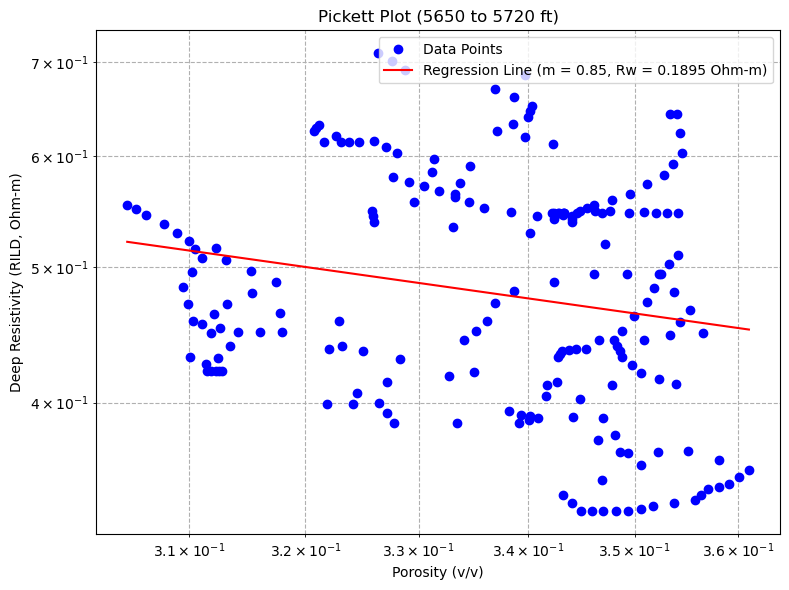

Archie's m exponent: 0.85
Formation water resistivity (Rw): 0.1895 Ohm-m
Salinity: -1266370.18-188846.25j ppm NaCl


In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the data
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Adjust filename if needed

# Clean column names to avoid KeyErrors
df.columns = df.columns.str.strip().str.upper()

# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ["RILD", "RHOB", "NPHI (SS UNI", "DEPTH", "GR"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing or invalid data in key columns
df = df.dropna(subset=numeric_columns)

# Define matrix and fluid densities (example for sandstone)
rho_ma = 2.65  # Matrix density (g/cm³)
rho_f = 1.0  # Fluid density (g/cm³)

# Calculate density porosity (DPHI)
df["DPHI"] = (rho_ma - df["RHOB"]) / (rho_ma - rho_f)

# Calculate average porosity (DPHI and NPHI)
df["PHI_AVG"] = (df["DPHI"] + df["NPHI (SS UNI"]) / 2

# Step 1: Extract data for the depth interval (5650 to 5720 ft)
depth_mask = (df["DEPTH"] >= 5655) & (df["DEPTH"] <= 5720)
df_interval = df[depth_mask]

# Step 2: Apply aquifer criteria to the depth interval
aquifer_mask = (
    (df_interval["GR"] < 75) &  # Low GR (clean formation)
    (df_interval["RILD"] < 100) &  # Low resistivity (water-bearing)
    (np.abs(df_interval["DPHI"] - df_interval["NPHI (SS UNI"]) < 0.05) &  # DPHI ≈ NPHI
    (df_interval["PHI_AVG"] > 0.05) & (df_interval["PHI_AVG"] < 0.4)  # Reasonable porosity range
)
aquifer_data = df_interval[aquifer_mask]

# Extract porosity and deep resistivity for the aquifer interval
phi = aquifer_data["PHI_AVG"]
Rt = aquifer_data["RILD"]

# Remove outliers (e.g., resistivity < 0.1 Ohm-m or porosity > 0.4)
outlier_mask = (Rt > 0.1) & (Rt < 100) & (phi > 0.05) & (phi < 0.4)
phi = phi[outlier_mask]
Rt = Rt[outlier_mask]

# Step 3: Construct the Pickett plot
plt.figure(figsize=(8, 6))
plt.loglog(phi, Rt, "bo", label="Data Points")
plt.xlabel("Porosity (v/v)")
plt.ylabel("Deep Resistivity (RILD, Ohm-m)")
plt.title("Pickett Plot (5650 to 5720 ft)")
plt.grid(True, which="both", linestyle="--")

# Step 4: Perform linear regression on log-transformed data
log_phi = np.log10(phi)
log_Rt = np.log10(Rt)
slope, intercept, r_value, p_value, std_err = linregress(log_phi, log_Rt)

# Step 5: Estimate Archie's m and Rw
m = -slope  # Archie's cementation exponent
a = 1.0  # Tortuosity factor (assumed for sandstones)
log_aRw = intercept
Rw = 10**log_aRw / a  # Formation water resistivity

# Step 6: Plot the regression line
phi_fit = np.logspace(np.log10(phi.min()), np.log10(phi.max()), 100)
Rt_fit = 10**(intercept + slope * np.log10(phi_fit))
plt.loglog(phi_fit, Rt_fit, "r-", label=f"Regression Line (m = {m:.2f}, Rw = {Rw:.4f} Ohm-m)")
plt.legend(loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

# Step 7: Calculate salinity in NaCl ppm
# Use the empirical relationship: R_w = 0.0123 + (3647.5 / salinity)^0.955
if Rw > 0.0123:  # Ensure Rw is valid for the salinity calculation
    salinity = (3647.5 / (0.006936 - 0.0123))**(1 / 0.955)
else:
    salinity = np.nan  # Invalid Rw

# Print results
print(f"Archie's m exponent: {m:.2f}")
print(f"Formation water resistivity (Rw): {Rw:.4f} Ohm-m")
print(f"Salinity: {salinity:.2f} ppm NaCl")

Depth (ft) | Porosity (φ) | RILD (R_t) | Hydrocarbon Saturation (S_h)
------------------------------------------------------------
   5302.5 |      0.4121 |     0.9028 |                    0.7909
   5345.5 |      0.3930 |     0.9662 |                    0.7877
   5372.5 |      0.3943 |     0.9974 |                    0.7919
   5404.0 |      0.3720 |     0.9445 |                    0.7725
   5435.0 |      0.4202 |     0.9403 |                    0.7994
   5471.0 |      0.2949 |     1.2625 |                    0.7497
   5500.5 |      0.3183 |     2.2681 |                    0.8289
   5511.5 |      0.3262 |     2.3492 |                    0.8363
   5522.5 |      0.3319 |     2.7282 |                    0.8511
   5528.0 |      0.3095 |     2.8085 |                    0.8421
   5542.5 |      0.3708 |    37.8098 |                    0.9656
   5551.0 |      0.3797 |    24.9174 |                    0.9584
   5556.0 |      0.3940 |     7.8439 |                    0.9277
   5574.5 |      0.3627 

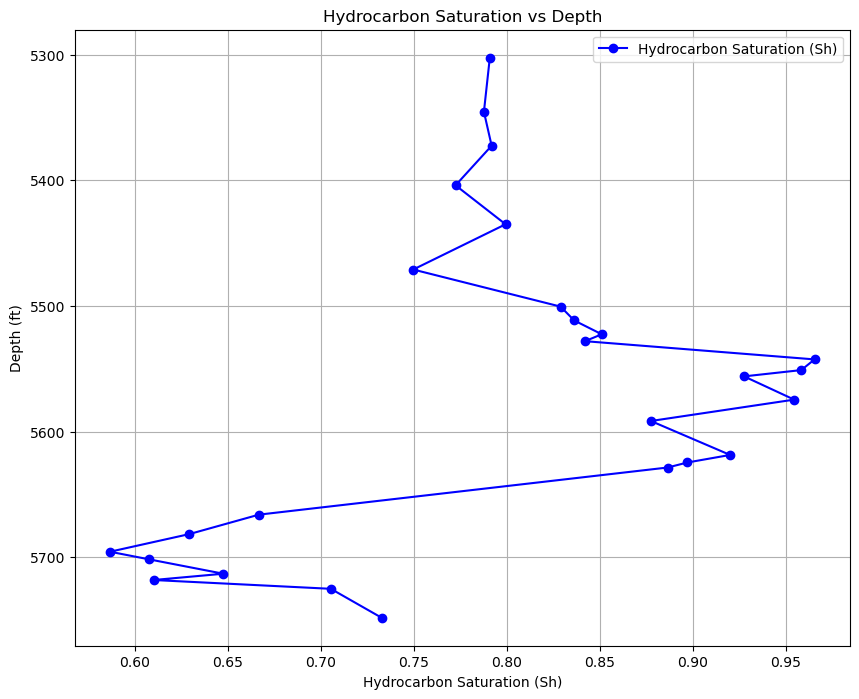

In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants
a = 1
m = 2.05
n = 1.95
Rw = 0.006936

# Provided sandstone porosity and depths
sandstone_data = {
    5302.5: 0.4121,
    5345.5: 0.3930,
    5372.5: 0.3943,
    5404.0: 0.3720,
    5435.0: 0.4202,
    5471.0: 0.2949,
    5500.5: 0.3183,
    5511.5: 0.3262,
    5522.5: 0.3319,
    5528.0: 0.3095,
    5542.5: 0.3708,
    5551.0: 0.3797,
    5556.0: 0.3940,
    5574.5: 0.3627,
    5591.5: 0.3643,
    5618.5: 0.3667,
    5624.5: 0.3710,
    5628.5: 0.3790,
    5666.0: 0.3336,
    5681.5: 0.3427,
    5695.5: 0.3124,
    5701.5: 0.3468,
    5713.0: 0.3534,
    5718.0: 0.3132,
    5725.0: 0.2994,
    5748.0: 0.3142
}

# Load the Excel file
df = pd.read_excel("HW2_data (2).xlsx", skiprows=37)  # Replace with your actual file path

# Assuming the Excel file has columns 'Depth' and 'RILD'
# Replace 'Depth' and 'RILD' with the actual column names in your file
depths = df['DEPTH'].values
rild_values = df['RILD'].values

# Function to calculate Sh
def calculate_sh(phi, rt):
    sw = ((a * Rw) / (phi ** m * rt)) ** (1 / n)
    return 1 - sw

# Prepare data for plotting
sh_values = []
sh_depths = []

# Print header for the output
print("Depth (ft) | Porosity (φ) | RILD (R_t) | Hydrocarbon Saturation (S_h)")
print("-" * 60)

for depth, phi in sandstone_data.items():
    # Find the closest depth in the Excel data
    idx = np.abs(depths - depth).argmin()
    rt = rild_values[idx]
    
    sh = calculate_sh(phi, rt)
    sh_values.append(sh)
    sh_depths.append(depth)
    
    # Print depth, porosity, RILD, and Sh
    print(f"{depth:9.1f} | {phi:11.4f} | {rt:10.4f} | {sh:25.4f}")

# Plotting
plt.figure(figsize=(10, 8))
plt.plot(sh_values, sh_depths, 'bo-', label='Hydrocarbon Saturation (Sh)')
plt.gca().invert_yaxis()  # Invert y-axis to show depth increasing downwards
plt.xlabel('Hydrocarbon Saturation (Sh)')
plt.ylabel('Depth (ft)')
plt.title('Hydrocarbon Saturation vs Depth')
plt.grid(True)
plt.legend()
plt.show()